# Python Notebook 1: Data Understanding and Preprocessing

Author: Santosh Manoharadas  
Student ID: w1954095 / 20220967  
Module: 5DATA002W.2 Machine Learning and Data Mining



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for cleaner plots
sns.set_style('whitegrid')

# Set matplotlib figure size default
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Section 2 - Load the Dataset
Loading a CSV Dataset into a DataFrame

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML CWK/loan_approval_data.csv')

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 58645 rows × 13 columns


,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


## Section 3 - Variable Selection (Domain Understanding)
Displaying Column Names and Data Types

In [ ]:
print("All columns in the dataset:")
print(df.columns.tolist())
print("\nColumn data types:")
print(df.dtypes)

All columns in the dataset:
['id', 'age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']

Column data types:
id                           int64
age                        float64
income                       int64
home_ownership              object
emplyment_length             int64
loan_intent                 object
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file     object
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object


## Section 4 - Descriptive Statistics (Task 2 - Case Study A)
Generating Descriptive Statistics

In [ ]:
# Define retained input features and target for Case Study A (classification)
classification_features = [
    'age', 'income', 'home_ownership', 'emplyment_length',
    'loan_intent', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file',
    'credit_history_length', 'loan_approval_status'
]

# Create the classification working dataset with only retained variables
df_cls = df[classification_features].copy()

# Display descriptive statistics for numeric variables
print("Descriptive Statistics - Numeric Variables:")
df_cls.describe()

Descriptive Statistics - Numeric Variables:


,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status
count,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000
mean,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382
std,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


In [ ]:
# Display descriptive statistics including categorical (object) columns
print("Descriptive Statistics - All Variables (including categorical):")
df_cls.describe(include='all')

Descriptive Statistics - All Variables (including categorical):


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
count,58639.000000,5.864500e+04,58645,58645.000000,58645,58645.000000,58634.000000,58645.000000,58640,58645.000000,58645.000000
unique,NaN,NaN,4,NaN,6,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,NaN,NaN,NaN,N,NaN,NaN
freq,NaN,NaN,30594,NaN,12271,NaN,NaN,NaN,49940,NaN,NaN
mean,27.550913,6.404617e+04,NaN,4.703487,NaN,9217.556518,10.677526,0.159238,NaN,5.813556,0.142382
std,6.033217,3.793111e+04,NaN,4.004982,NaN,5563.807384,3.036034,0.091692,NaN,4.029196,0.349445
min,20.000000,4.200000e+03,NaN,0.000000,NaN,500.000000,-11.140000,0.000000,NaN,2.000000,0.000000
25%,23.000000,4.200000e+04,NaN,2.000000,NaN,5000.000000,7.880000,0.090000,NaN,3.000000,0.000000
50%,26.000000,5.800000e+04,NaN,4.000000,NaN,8000.000000,10.750000,0.140000,NaN,4.000000,0.000000
75%,30.000000,7.560000e+04,NaN,7.000000,NaN,12000.000000,12.990000,0.210000,NaN,8.000000,0.000000


In [ ]:
# Display the variable scale type (dtype) and example values for all retained variables
print(f"{'Variable':<30} {'Scale/Type':<15} {'Example Values'}")
print("-" * 70)
# Loop through each retained column and print its type and sample values
for col in df_cls.columns:
    sample = df_cls[col].dropna().unique()[:3].tolist()
    print(f"{col:<30} {str(df_cls[col].dtype):<15} {sample}")

Variable                       Scale/Type      Example Values
----------------------------------------------------------------------
age                            float64         [21.0, 23.0, 40.0]
income                         int64           [12000, 13200, 9600]
home_ownership                 object          ['OWN', 'RENT', 'MORTGAGE']
emplyment_length               int64           [0, 2, 5]
loan_intent                    object          ['EDUCATION', 'MEDICAL', 'HOMEIMPROVEMENT']
loan_amount                    int64           [15000, 25000, 30000]
loan_interest_rate             float64         [6.99, 16.77, 12.42]
loan_income_ratio              float64         [0.12, 0.19, 0.31]
payment_default_on_file        object          ['N', 'Y']
credit_history_length          int64           [4, 3, 11]
loan_approval_status           int64           [0, 1]


### Target Variable Distribution - Loan Approval Status
Plotting Target Variable Distribution

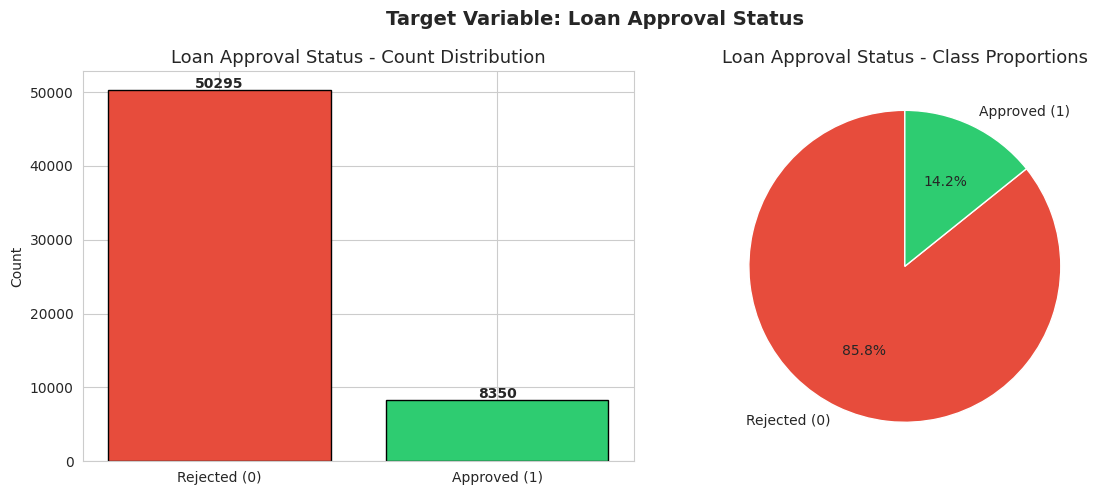

Rejected (0): 50,295  (85.8%)
Approved (1): 8,350  (14.2%)

Note: The dataset is imbalanced - majority class is 'Rejected'.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
status_counts = df_cls['loan_approval_status'].value_counts()
axes[0].bar(['Rejected (0)', 'Approved (1)'], status_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
# Add count labels on each bar
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')
axes[0].set_title('Loan Approval Status - Count Distribution', fontsize=13)
axes[0].set_ylabel('Count')

# Pie chart showing class proportions
axes[1].pie(status_counts.values,
            labels=['Rejected (0)', 'Approved (1)'],
            autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Loan Approval Status - Class Proportions', fontsize=13)

plt.suptitle('Target Variable: Loan Approval Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the class counts and percentages
print(f"Rejected (0): {status_counts[0]:,}  ({status_counts[0]/len(df_cls)*100:.1f}%)")
print(f"Approved (1): {status_counts[1]:,}  ({status_counts[1]/len(df_cls)*100:.1f}%)")
print(f"\nNote: The dataset is imbalanced - majority class is 'Rejected'.")

## Section 5 - Data Quality Check: Identifying Issues (Task 3a - Case Study A)
Checking for Missing Values, Outliers and Inconsistencies

In [ ]:
print("Missing Values per Column:")
missing = df_cls.isnull().sum()
# Filter and display only columns that have at least one missing value
missing_cols = missing[missing > 0]
for col, count in missing_cols.items():
    pct = count / len(df_cls) * 100
    print(f"  {col}: {count} missing ({pct:.2f}%)")
print(f"\nTotal missing values: {missing.sum()}")

Missing Values per Column:
  age: 6 missing (0.01%)
  loan_interest_rate: 11 missing (0.02%)
  payment_default_on_file: 5 missing (0.01%)

Total missing values: 22


In [ ]:
duplicates = df_cls.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [ ]:
# Check the 'age' column for unrealistic/outlier values
print("Age column - distribution summary:")
print(df_cls['age'].describe())
age_outliers = df_cls[df_cls['age'] > 100]
print(f"\nRows with age > 100: {len(age_outliers)}")
print(age_outliers[['age', 'income', 'loan_approval_status']])

Age column - distribution summary:
count    58639.000000
mean        27.550913
std          6.033217
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        123.000000
Name: age, dtype: float64

Rows with age > 100: 1
         age  income  loan_approval_status
39792  123.0   36000                     0


In [ ]:
# Check 'income' for any zero or negative values (data entry error)
print("Income - zero or negative values:")
print(df_cls[df_cls['income'] <= 0][['income']].shape[0])

# Check 'loan_amount' for zero or negative values
print("\nLoan amount - zero or negative values:")
print(df_cls[df_cls['loan_amount'] <= 0].shape[0])

# Check 'loan_interest_rate' for zero values (would indicate free loan - suspicious)
print("\nLoan interest rate = 0 values:")
print(df_cls[df_cls['loan_interest_rate'] == 0].shape[0])

Income - zero or negative values:
0

Loan amount - zero or negative values:
0

Loan interest rate = 0 values:
0


In [ ]:
# Check unique values in categorical columns for unexpected entries
for col in ['home_ownership', 'loan_intent', 'payment_default_on_file']:
    print(f"{col} - unique values: {df_cls[col].unique().tolist()}")

home_ownership - unique values: ['OWN', 'RENT', 'MORTGAGE', 'OTHER']
loan_intent - unique values: ['EDUCATION', 'MEDICAL', 'HOMEIMPROVEMENT', 'VENTURE', 'DEBTCONSOLIDATION', 'PERSONAL']
payment_default_on_file - unique values: ['N', 'Y', nan]


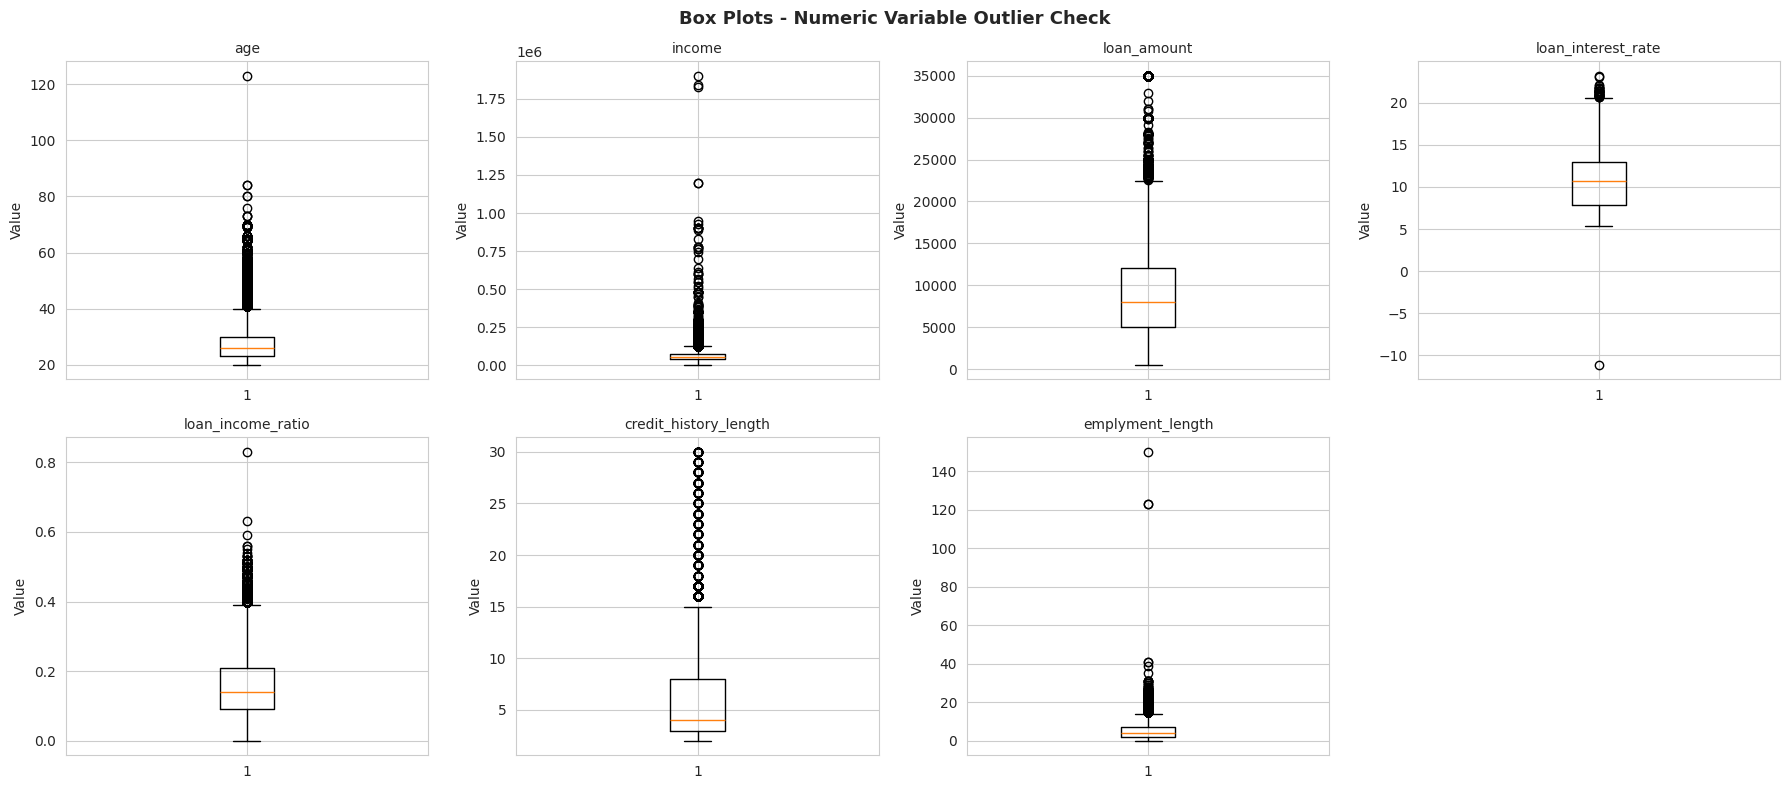

In [ ]:
# Visualise the distribution of key numeric variables to spot outliers
numeric_cols = ['age', 'income', 'loan_amount', 'loan_interest_rate',
                'loan_income_ratio', 'credit_history_length', 'emplyment_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

# Loop through each numeric column and plot a box plot
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_cls[col].dropna())
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')

# Hide the unused subplot
axes[-1].set_visible(False)

plt.suptitle('Box Plots - Numeric Variable Outlier Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6 - Data Cleaning and Transformation (Task 3b - Case Study A)
Implementing Data Cleaning and Encoding

In [ ]:
# --- FIX 1: Handle missing values in 'age' ---
print("BEFORE - Missing 'age' values:", df_cls['age'].isnull().sum())
age_median = df_cls[df_cls['age'] <= 100]['age'].median()
print(f"Age median (from valid values): {age_median}")
df_cls['age'] = df_cls['age'].apply(
    lambda x: age_median if (pd.isnull(x) or x > 100) else x
)

# Show 'age' missing count AFTER fix
print("AFTER  - Missing 'age' values:", df_cls['age'].isnull().sum())
print("AFTER  - Age > 100 values:", (df_cls['age'] > 100).sum())

BEFORE - Missing 'age' values: 6
Age median (from valid values): 26.0
AFTER  - Missing 'age' values: 0
AFTER  - Age > 100 values: 0


In [ ]:
# --- FIX 2: Handle missing values in 'loan_interest_rate' ---

# Show missing count BEFORE fix
print("BEFORE - Missing 'loan_interest_rate' values:", df_cls['loan_interest_rate'].isnull().sum())

# Calculate the median interest rate
rate_median = df_cls['loan_interest_rate'].median()
print(f"Loan interest rate median: {rate_median}")

# Fill missing values with the median
df_cls['loan_interest_rate'] = df_cls['loan_interest_rate'].fillna(rate_median)

# Show missing count AFTER fix
print("AFTER  - Missing 'loan_interest_rate' values:", df_cls['loan_interest_rate'].isnull().sum())

BEFORE - Missing 'loan_interest_rate' values: 11
Loan interest rate median: 10.75
AFTER  - Missing 'loan_interest_rate' values: 0


In [ ]:
# --- FIX 3: Handle missing values in 'payment_default_on_file' ---

# Show missing count BEFORE fix
print("BEFORE - Missing 'payment_default_on_file' values:", df_cls['payment_default_on_file'].isnull().sum())

# Calculate the mode (most frequent category)
pdef_mode = df_cls['payment_default_on_file'].mode()[0]
print(f"Mode value: '{pdef_mode}'")

# Fill missing values with the mode
df_cls['payment_default_on_file'] = df_cls['payment_default_on_file'].fillna(pdef_mode)

# Show missing count AFTER fix
print("AFTER  - Missing 'payment_default_on_file' values:", df_cls['payment_default_on_file'].isnull().sum())

BEFORE - Missing 'payment_default_on_file' values: 5
Mode value: 'N'
AFTER  - Missing 'payment_default_on_file' values: 0


In [ ]:
# --- FIX 4: Encode binary categorical column 'payment_default_on_file' ---

# Show unique values BEFORE encoding
print("BEFORE - Unique values:", df_cls['payment_default_on_file'].unique())

# Map 'Y' (default on file) to 1, 'N' (no default) to 0
df_cls['payment_default_on_file'] = df_cls['payment_default_on_file'].map({'Y': 1, 'N': 0})

# Show unique values AFTER encoding
print("AFTER  - Unique values:", df_cls['payment_default_on_file'].unique())

BEFORE - Unique values: ['N' 'Y']
AFTER  - Unique values: [0 1]


In [ ]:
# --- FIX 5: Encode multi-category categorical variables with Label Encoding ---
from sklearn.preprocessing import LabelEncoder
le_home = LabelEncoder()
le_intent = LabelEncoder()


# Encode 'home_ownership' column (OWN, RENT, MORTGAGE, OTHER → numeric)
print("BEFORE 'home_ownership':", df_cls['home_ownership'].unique())
df_cls['home_ownership'] = le_home.fit_transform(df_cls['home_ownership'])
print("AFTER  'home_ownership':", df_cls['home_ownership'].unique())

# Encode 'loan_intent' column (EDUCATION, MEDICAL, etc. → numeric)
print("\nBEFORE 'loan_intent':", df_cls['loan_intent'].unique())
df_cls['loan_intent'] = le_intent.fit_transform(df_cls['loan_intent'])
print("AFTER  'loan_intent':", df_cls['loan_intent'].unique())

BEFORE 'home_ownership': ['OWN' 'RENT' 'MORTGAGE' 'OTHER']
AFTER  'home_ownership': [2 3 0 1]

BEFORE 'loan_intent': ['EDUCATION' 'MEDICAL' 'HOMEIMPROVEMENT' 'VENTURE' 'DEBTCONSOLIDATION'
 'PERSONAL']
AFTER  'loan_intent': [1 3 2 5 0 4]


In [ ]:
# Confirm no missing values remain in the classification dataset
print("Final missing value check - Classification Dataset:")
remaining_missing = df_cls.isnull().sum().sum()
print(f"Total missing values remaining: {remaining_missing}")

# Show final shape and data types
print(f"\nFinal classification dataset shape: {df_cls.shape}")
print(df_cls.dtypes)

Final missing value check - Classification Dataset:
Total missing values remaining: 0

Final classification dataset shape: (58645, 11)
age                        float64
income                       int64
home_ownership               int64
emplyment_length             int64
loan_intent                  int64
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file      int64
credit_history_length        int64
loan_approval_status         int64
dtype: object


## Section 7 - Produce Final Classification Dataset (Case Study A)
Saving the Prepared Dataset

In [ ]:
X_cls = df_cls.drop(columns=['loan_approval_status'])
y_cls = df_cls['loan_approval_status']

# Display the list of feature names and the data shape
print("Classification Input Features:")
print(X_cls.columns.tolist())
print(f"\nFeature matrix shape: {X_cls.shape}")
print(f"Target vector shape: {y_cls.shape}")
print(f"Target class distribution:\n{y_cls.value_counts()}")

Classification Input Features:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Feature matrix shape: (58645, 10)
Target vector shape: (58645,)
Target class distribution:
loan_approval_status
0    50295
1     8350
Name: count, dtype: int64


In [ ]:
# Save the cleaned classification dataset to a CSV file for use in Notebook 2
df_cls.to_csv('loan_classification_clean.csv', index=False)
print("Classification dataset saved as: loan_classification_clean.csv")

Classification dataset saved as: loan_classification_clean.csv


In [ ]:
from google.colab import files
files.download('loan_classification_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 8 - Prepare Regression Dataset (Case Study B)
Subsetting Data for Regression Modelling

In [ ]:
# Build the regression dataset from the original raw dataframe
# Start with a fresh copy of original data with required columns
regression_cols = [
    'age', 'income', 'home_ownership', 'emplyment_length',
    'loan_intent', 'loan_amount', 'loan_interest_rate',
    'loan_income_ratio', 'payment_default_on_file',
    'credit_history_length', 'max_allowed_loan'
]

# Filter the original dataframe for the regression subset (positive max_allowed_loan)
df_reg = df[regression_cols + ['loan_approval_status']].copy()

# Keep only rows where max_allowed_loan is a valid positive value
df_reg = df_reg[df_reg['max_allowed_loan'] > 0].copy()
print(f"Rows with valid positive max_allowed_loan: {len(df_reg)}")

Rows with valid positive max_allowed_loan: 50292


In [ ]:
# Apply the same cleaning steps used in the classification dataset to the regression dataset

# Fix: Replace missing and outlier age values with the median
age_med_reg = df_reg[df_reg['age'] <= 100]['age'].median()
df_reg['age'] = df_reg['age'].apply(lambda x: age_med_reg if (pd.isnull(x) or x > 100) else x)

# Fix: Impute missing loan_interest_rate with median
df_reg['loan_interest_rate'] = df_reg['loan_interest_rate'].fillna(df_reg['loan_interest_rate'].median())

# Fix: Impute missing payment_default_on_file with mode
df_reg['payment_default_on_file'] = df_reg['payment_default_on_file'].fillna(
    df_reg['payment_default_on_file'].mode()[0]
)

# Fix: Binary encode payment_default_on_file
df_reg['payment_default_on_file'] = df_reg['payment_default_on_file'].map({'Y': 1, 'N': 0})

# Fix: Label encode home_ownership
df_reg['home_ownership'] = LabelEncoder().fit_transform(df_reg['home_ownership'])

# Fix: Label encode loan_intent
df_reg['loan_intent'] = LabelEncoder().fit_transform(df_reg['loan_intent'])

# Confirm no missing values remain
print("Regression dataset - missing values remaining:", df_reg.isnull().sum().sum())
print(f"Regression dataset shape: {df_reg.shape}")

Regression dataset - missing values remaining: 0
Regression dataset shape: (50292, 12)


In [ ]:
# Define features and target for regression (excluding the approval status column)
X_reg = df_reg.drop(columns=['max_allowed_loan', 'loan_approval_status'])
y_reg = df_reg['max_allowed_loan']

# Display the feature names and data dimensions for the regression dataset
print("Regression Input Features:")
print(X_reg.columns.tolist())
print(f"\nFeature matrix shape: {X_reg.shape}")
print(f"Target vector shape: {y_reg.shape}")
print(f"\nTarget (max_allowed_loan) summary:")
print(y_reg.describe())

Regression Input Features:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Feature matrix shape: (50292, 10)
Target vector shape: (50292,)

Target (max_allowed_loan) summary:
count    5.029200e+04
mean     8.139253e+04
std      5.812145e+04
min      2.320000e+02
25%      4.911050e+04
50%      6.943150e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


In [ ]:
# Save the regression dataset to CSV for use in Notebook 3
df_reg.to_csv('loan_regression_clean.csv', index=False)
print("Regression dataset saved as: loan_regression_clean.csv")

Regression dataset saved as: loan_regression_clean.csv


In [ ]:
files.download('loan_regression_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 9 - Exploratory Visualisations
Exploratory Data Analysis Visualisations

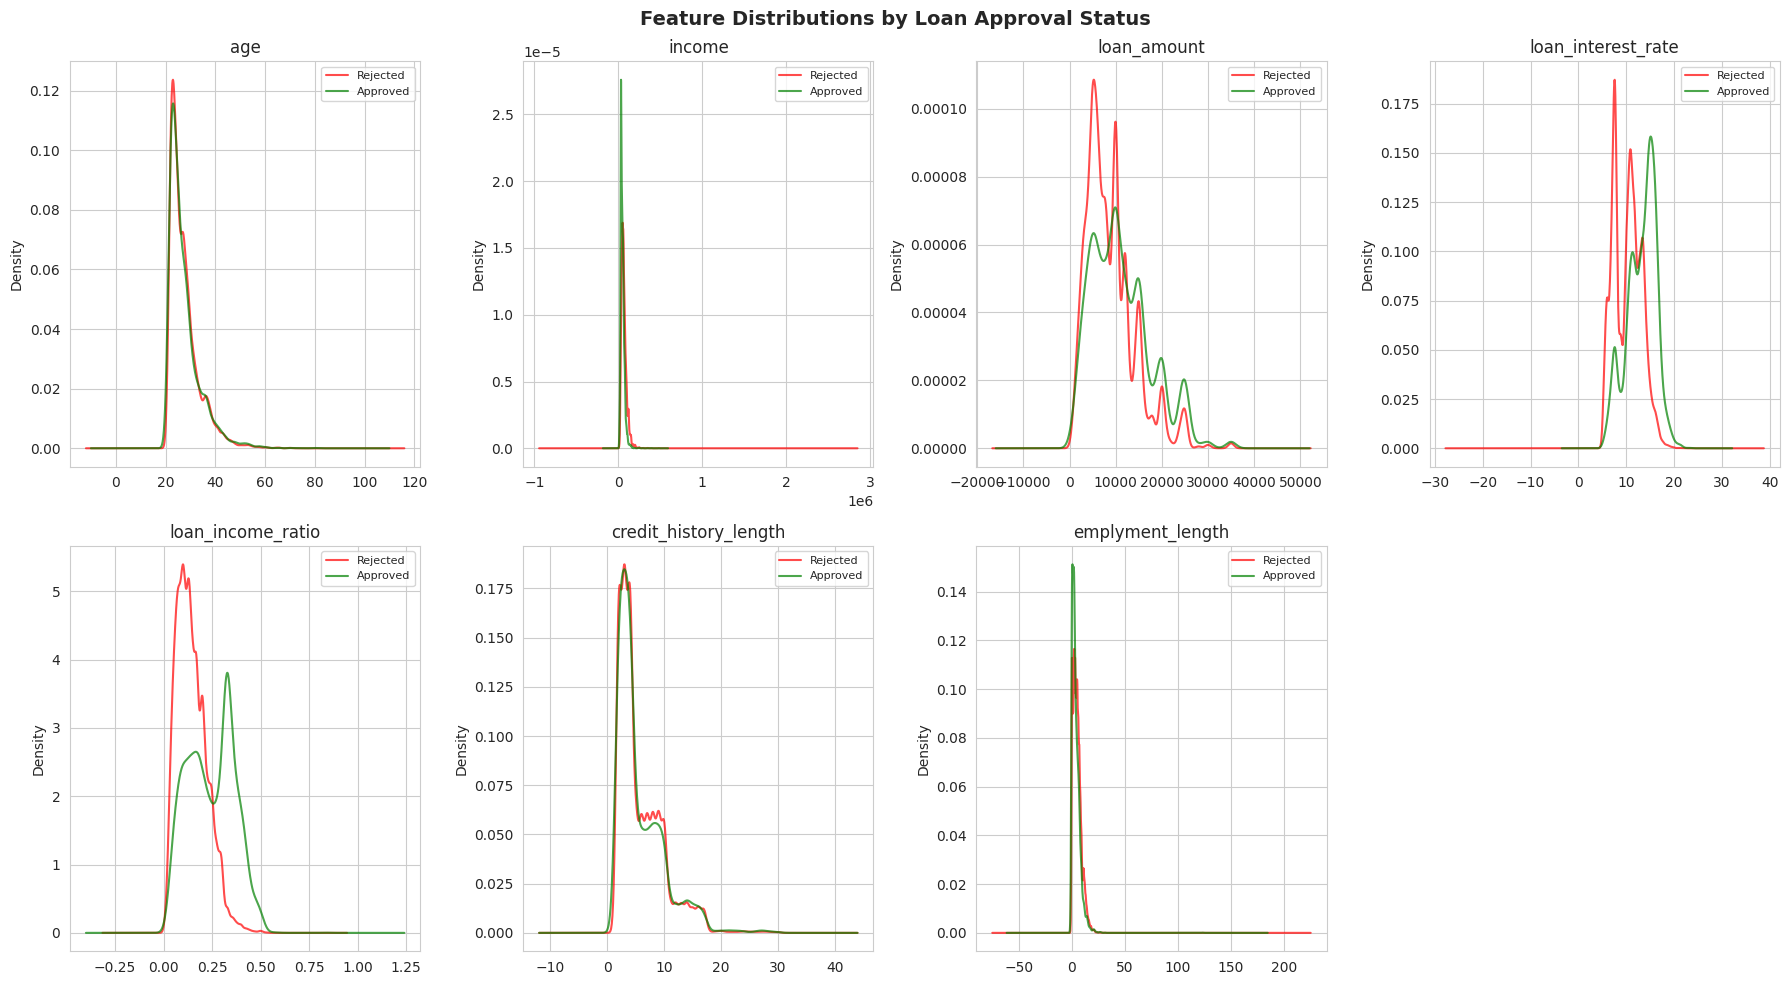

In [ ]:
# Plot distributions of all numeric features split by loan approval status
numeric_features = ['age', 'income', 'loan_amount', 'loan_interest_rate',
                    'loan_income_ratio', 'credit_history_length', 'emplyment_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

# Plot KDE distribution for each numeric feature, coloured by approval status
for i, col in enumerate(numeric_features):
    # Plot distribution for Rejected (0)
    df_cls[df_cls['loan_approval_status'] == 0][col].plot.kde(
        ax=axes[i], label='Rejected', color='red', alpha=0.7)
    # Plot distribution for Approved (1)
    df_cls[df_cls['loan_approval_status'] == 1][col].plot.kde(
        ax=axes[i], label='Approved', color='green', alpha=0.7)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Loan Approval Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

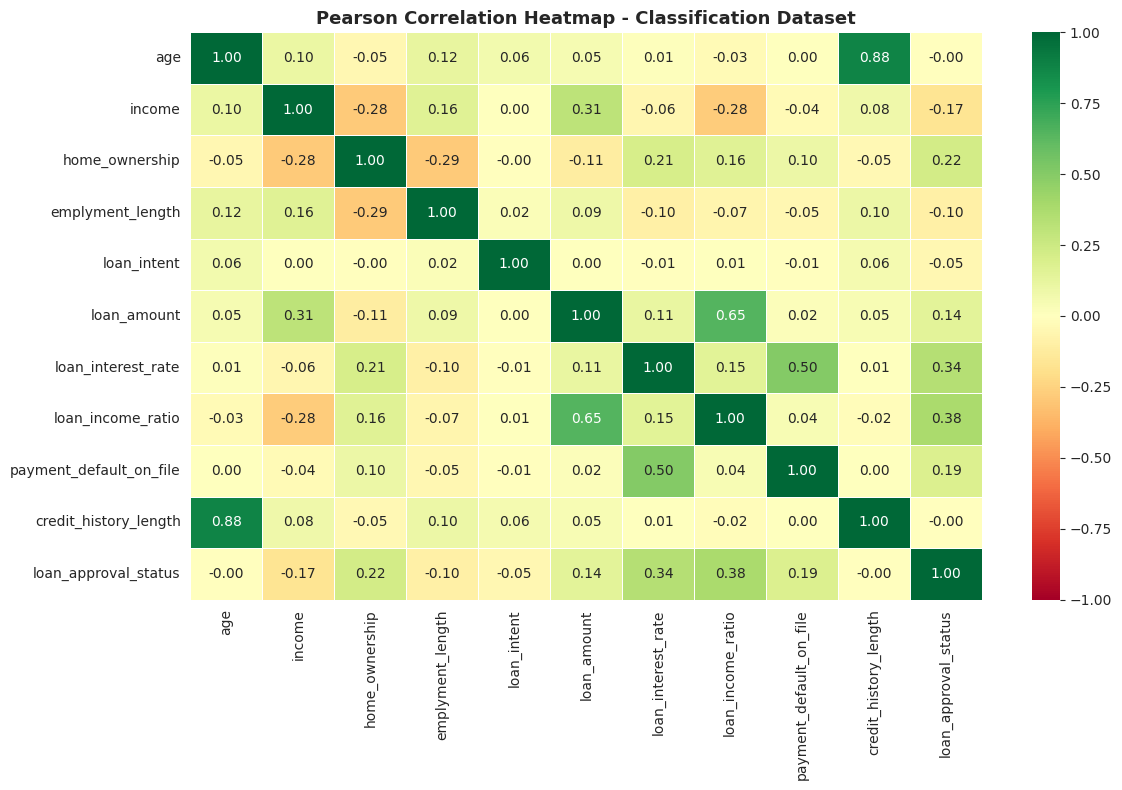

In [ ]:
plt.figure(figsize=(12, 8))

# Compute pairwise Pearson correlation of all numeric columns
corr_matrix = df_cls.corr(numeric_only=True)

# Draw the heatmap with annotation
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap - Classification Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 10 - Summary


### References
- Géron, A. (2019) *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. 2nd edn. O'Reilly Media.
